In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
df = pd.read_csv('HousingData.csv')

In [51]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [52]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [53]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [54]:
df.shape

(506, 14)

In [55]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [56]:
df['AGE'].isna().sum()

np.int64(0)

In [57]:
med_col= ['CRIM','INDUS','CHAS','LSTAT']
df[med_col] = df[med_col].fillna(df[med_col].mean())

In [58]:
df.isna().sum()

,0
CRIM,0
ZN,20
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [59]:
df['ZN'] = df['ZN'].fillna(df['ZN'].mean())


In [60]:
df.shape

(506, 14)

In [61]:
df.duplicated().sum()

np.int64(0)

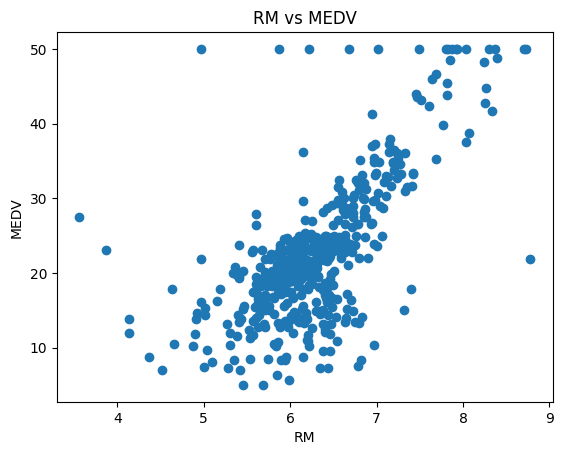

In [62]:
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('RM vs MEDV')
plt.show()


In [63]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [66]:
model = RandomForestRegressor(
    n_estimators=50,
    criterion='squared_error',
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [67]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)

Prediction [23.3   30.778 17.172 23.788 16.214 21.496 18.752 16.29  21.188 21.278
 19.886 18.706  8.928 21.44  19.978 24.596 19.306  8.238 45.908 14.144
 23.494 24.338 14.656 21.596 13.88  15.096 21.168 13.78  19.228 21.164
 20.132 23.032 27.34  17.898 15.668 15.39  34.058 19.512 20.684 22.824
 18.2   29.434 45.842 19.254 22.606 12.846 15.092 24.702 18.646 29.216
 21.17  33.088 16.042 26.286 45.32  21.502 14.706 31.756 22.238 18.416
 26.004 34.132 29.534 18.776 26.528 17.962 12.43  23.202 28.548 15.314
 20.778 26.078  9.6   21.028 21.666  7.25  20.132 45.872 11.586 13.62
 21.282 12.486 20.424  8.81  21.162 28.226 16.424 23.34  24.158 17.78
 22.042  8.312 18.764 19.568 21.424 18.822 43.328 13.524 12.422 14.218
 20.198 23.492]


In [68]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error",mae)
r2_score = r2_score(y_test,y_pred)
print("R2 Score",r2_score)

Mean Absolute Error 2.018666666666667
R2 Score 0.8990852949470741


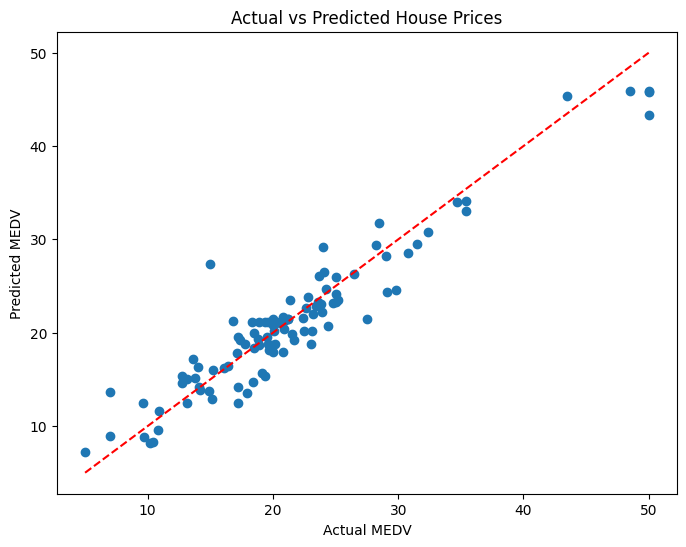

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [70]:
df.tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
505,0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88,11.9


In [71]:
model.predict([[0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([15.72])

In [72]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result['Difference'] = result['Actual'] - result['Predicted']

print(result.head(20))

     Actual  Predicted  Difference
173    23.6     23.300       0.300
274    32.4     30.778       1.622
491    13.6     17.172      -3.572
72     22.8     23.788      -0.988
452    16.1     16.214      -0.114
76     20.0     21.496      -1.496
316    17.8     18.752      -0.952
140    14.0     16.290      -2.290
471    19.6     21.188      -1.588
500    16.8     21.278      -4.478
218    21.5     19.886       1.614
9      18.9     18.706       0.194
414     7.0      8.928      -1.928
78     21.2     21.440      -0.240
323    18.5     19.978      -1.478
473    29.8     24.596       5.204
124    18.8     19.306      -0.506
388    10.2      8.238       1.962
195    50.0     45.908       4.092
448    14.1     14.144      -0.044


In [73]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9733613457945516
Test R2: 0.8990852949470741


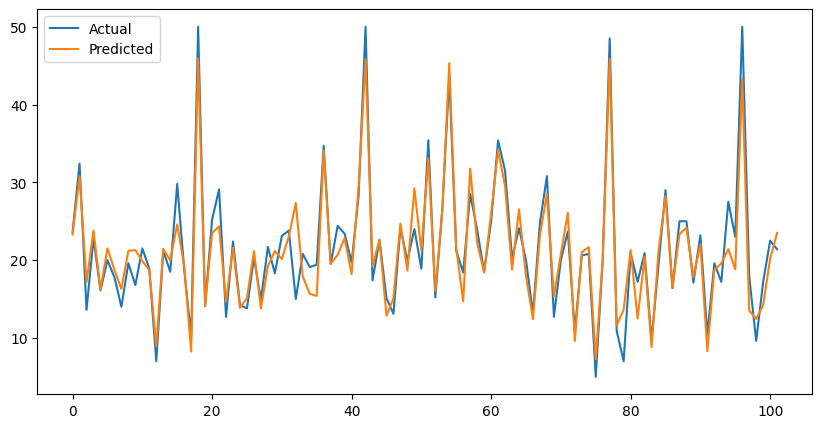

In [74]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()
plt.show()